<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/Airline_Crew_Pairing_Rostering_Qiskit_QML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Airline Crew Pairing & Rostering
## Uçtan Uca Quantum Machine Learning (Qiskit + QAOA)

**Hazırlayan:** Joseph Volkan Ozcan  
**Amaç:** Havayolu mürettebat planlama problemini klasik optimizasyondan QUBO formülasyonuna, oradan da Qiskit QAOA ile çözmeye kadar uçtan uca anlatmak.

---

### İçindekiler
1. Problem Tanımı (Crew Pairing vs Rostering)
2. Klasik Matematiksel Model (Set Partitioning)
3. Toy Problem Örneği
4. QUBO Formülasyonu
5. Qiskit ile QAOA Uygulaması
6. Sonuçların Yorumlanması
7. Alıştırmalar ve İleri Okumalar

> **Not:** Bu notebook Colab’da çalışacak şekilde tasarlanmıştır. Gerçek ölçekli havayolu problemleri binlerce değişken içerir; burada pedagojik bir toy instance kullanıyoruz.

## 0. Ortam Kurulumu

Aşağıdaki hücreyi çalıştırarak gerekli kütüphaneleri yükleyin.

In [ ]:
# Colab için gerekli paketler
# Not: qiskit-aer opsiyoneldir; StatevectorSampler için zorunlu değil.
!pip install -q "qiskit>=1.0" qiskit-algorithms qiskit-optimization matplotlib networkx pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Dict, Tuple

# Qiskit & Algorithms
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import QAOA, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_algorithms.utils import algorithm_globals
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.algorithms import MinimumEigenOptimizer

print("Kütüphaneler başarıyla yüklendi ✅")

Kütüphaneler başarıyla yüklendi ✅


## 1. Problem Tanımı: Crew Pairing & Rostering

Havayolu operasyonlarında mürettebat planlama **en pahalı** ve **en karmaşık** optimizasyon problemlerinden biridir. Genellikle iki ana alt probleme ayrılır:

### 1.1 Crew Pairing (Eşleştirme)
- **Amaç:** Uçuş bacaklarını (flight legs) birleştirerek **geçerli pairings** (görev dizileri) oluşturmak.
- Pairing: Aynı home base’ten başlayıp aynı base’e dönen, kurallara uygun uçuş + dinlenme dizisi.
- Kısıtlar: Maksimum uçuş saati, minimum dinlenme süresi, gece dinlenmesi, base dönüşü, maksimum pairing süresi vb.
- Klasik formülasyon: **Set Partitioning Problem** (her uçuş tam olarak bir pairing’e ait olmalı).

### 1.2 Crew Rostering / Assignment (Atama)
- Oluşturulan pairings’leri **bireysel mürettebat üyelerine** atamak.
- Ek kısıtlar: Sözleşme yüzdesi, kıdem, yetkinlik (type rating), tercih, yasal dinlenme, üs değişimi vb.
- Genellikle pairing’den sonra çözülür (sequential approach).

Bu notebook’ta odak noktamız **Crew Pairing** olacak çünkü QUBO / QAOA için daha doğal bir set partitioning yapısına sahiptir. Rostering de benzer şekilde QUBO’ya dönüştürülebilir (assignment problem + soft constraints).

### Neden Quantum?
- Problem NP-hard’dır.
- Gerçek örneklerde milyonlarca potansiyel pairing üretilir.
- QAOA ve Quantum Annealing gibi yöntemler, QUBO formülasyonları üzerinden heuristik çözümler sunabilir.
- Günümüz donanımı henüz endüstriyel ölçeğe yetmez; ancak formülasyon ve hybrid yaklaşımlar aktif araştırma konusudur (2024-2026 arXiv çalışmaları).

## 2. Klasik Matematiksel Model (Set Partitioning)

Crew Pairing genellikle şu şekilde modellenir:

$$
\begin{align*}
\min \quad & \sum_{j \in P} c_j x_j \\
\text{s.t.} \quad & \sum_{j \in P} a_{ij} x_j = 1 && \forall i \in F \\
& x_j \in \{0,1\} && \forall j \in P
\end{align*}
$$

Burada:
- $F$: Uçuş bacakları kümesi
- $P$: Geçerli pairings kümesi
- $x_j = 1$ ise $j$ pairing’i seçilir
- $a_{ij} = 1$ ise $i$ uçuşu $j$ pairing’inde yer alır
- $c_j$: Pairing maliyeti (ücret + hotel + deadhead + ...)

Bu model **Exact Cover / Set Partitioning** problemidir. Kısıtlar eşitlik olduğu için QUBO’ya ceza terimleri ile kolayca dönüştürülebilir.

## 3. Toy Problem: Küçük Ölçekli Örnek

Gerçek bir filoyu simüle etmek yerine, öğrencilerin formülasyonu net görmesi için **4 uçuş + 5 potansiyel pairing** içeren minik bir örnek kuralım.

### Senaryo
- Base: IST (İstanbul)
- Uçuşlar:
  - F1: IST → AYT (Antalya)
  - F2: AYT → IST
  - F3: IST → ESB (Ankara)
  - F4: ESB → IST

Geçerli pairings (elle üretilmiş):

| Pairing | Uçuşlar          | Maliyet | Açıklama                    |
|---------|------------------|---------|-----------------------------|
| P1      | F1-F2            | 10      | Antalya günübirlik          |
| P2      | F3-F4            | 12      | Ankara günübirlik           |
| P3      | F1-F2-F3-F4      | 25      | İki destinasyon, uzun       |
| P4      | F1               | 18      | Tek yön (deadhead gerekir)  |
| P5      | F3               | 15      | Tek yön                     |

> Not: Gerçekte pairing üretimi (pairing generation) ayrı bir column generation / enumeration adımıdır. Burada önceden üretilmiş varsayıyoruz.

In [ ]:
# Toy instance tanımı
flights = ["F1", "F2", "F3", "F4"]

pairings = {
    "P1": {"flights": ["F1", "F2"], "cost": 10},
    "P2": {"flights": ["F3", "F4"], "cost": 12},
    "P3": {"flights": ["F1", "F2", "F3", "F4"], "cost": 25},
    "P4": {"flights": ["F1"], "cost": 18},
    "P5": {"flights": ["F3"], "cost": 15},
}

# Coverage matrisi A (a_ij)
A = pd.DataFrame(0, index=flights, columns=pairings.keys())
for p_name, p_data in pairings.items():
    for f in p_data["flights"]:
        A.loc[f, p_name] = 1

costs = pd.Series({p: data["cost"] for p, data in pairings.items()})

print("Coverage Matrisi (A):")
display(A)
print("\nMaliyetler:")
display(costs)

Coverage Matrisi (A):


,P1,P2,P3,P4,P5
F1,1,0,1,1,0
F2,1,0,1,0,0
F3,0,1,1,0,1
F4,0,1,1,0,0



Maliyetler:


,0
P1,10
P2,12
P3,25
P4,18
P5,15


### Optimal Klasik Çözüm (Sezgisel)

En ucuz geçerli çözüm: **P1 + P2** → maliyet = 10 + 12 = **22**  
P3 tek başına da tüm uçuşları kaplar ama maliyeti 25’tir (daha pahalı).

## 4. QUBO Formülasyonu

Set Partitioning modelini QUBO’ya çevirmek için eşitlik kısıtlarını **ceza terimleri** ile objektife ekleriz:

$$
\min \quad \sum_j c_j x_j + \lambda \sum_i \left(1 - \sum_j a_{ij} x_j\right)^2
$$

Burada $\lambda$ yeterince büyük bir ceza katsayısıdır (maliyetlerden daha büyük seçilir).

Açılım:
$$
\left(1 - \sum_j a_{ij} x_j\right)^2 = 1 - 2\sum_j a_{ij}x_j + \sum_j \sum_k a_{ij}a_{ik}x_j x_k
$$

Sabit terimler ihmal edilebilir. Sonuçta pure quadratic + linear form elde ederiz → **QUBO**.

In [ ]:
def build_crew_pairing_qubo(A: pd.DataFrame, costs: pd.Series, penalty: float = 50.0) -> QuadraticProgram:
    """
    Set Partitioning modelini QuadraticProgram olarak oluşturur
    ve QUBO'ya çevirir.
    """
    qp = QuadraticProgram("CrewPairing")

    # Binary değişkenler
    for p in A.columns:
        qp.binary_var(name=p)

    # Objektif: maliyet
    linear = {p: float(costs[p]) for p in A.columns}
    qp.minimize(linear=linear)

    # Her uçuş için eşitlik kısıtı: sum a_ij x_j == 1
    for flight in A.index:
        constraint_dict = {p: int(A.loc[flight, p]) for p in A.columns if A.loc[flight, p] == 1}
        qp.linear_constraint(
            linear=constraint_dict,
            sense="==",
            rhs=1,
            name=f"cover_{flight}"
        )

    print("Orijinal QuadraticProgram:")
    print(qp.prettyprint())

    # QUBO'ya çevir
    converter = QuadraticProgramToQubo(penalty=penalty)
    qubo = converter.convert(qp)

    print("\nQUBO formu:")
    print(qubo.prettyprint())

    return qubo, converter

qubo, converter = build_crew_pairing_qubo(A, costs, penalty=50.0)

Orijinal QuadraticProgram:
Problem name: CrewPairing

Minimize
  10*P1 + 12*P2 + 25*P3 + 18*P4 + 15*P5

Subject to
  Linear constraints (4)
    P1 + P3 + P4 == 1  'cover_F1'
    P1 + P3 == 1  'cover_F2'
    P2 + P3 + P5 == 1  'cover_F3'
    P2 + P3 == 1  'cover_F4'

  Binary variables (5)
    P1 P2 P3 P4 P5


QUBO formu:
Problem name: CrewPairing

Minimize
  100*P1^2 + 200*P1*P3 + 100*P1*P4 + 100*P2^2 + 200*P2*P3 + 100*P2*P5 + 200*P3^2
  + 100*P3*P4 + 100*P3*P5 + 50*P4^2 + 50*P5^2 - 190*P1 - 188*P2 - 375*P3 - 82*P4
  - 85*P5 + 200

Subject to
  No constraints

  Binary variables (5)
    P1 P2 P3 P4 P5



## 5. Qiskit ile QAOA Çözümü

QAOA (Quantum Approximate Optimization Algorithm), varyasyonel bir quantum algoritmasıdır.  
Cost Hamiltonian’ı (Ising / QUBO) ve Mixer Hamiltonian’ı (genellikle X-mixer) kullanarak parametreli bir devre oluşturur. Klasik optimizer parametreleri ayarlar.

Adımlar:
1. QUBO → Ising Hamiltonian (SparsePauliOp)
2. QAOAAnsatz oluştur
3. Sampler + klasik optimizer ile minimize et
4. En iyi bitstring’i decode et

> **Önemli not (AerError):** Eski `SamplerV2` / Aer kombinasyonlarında `unknown instruction: QAOA` hatası alınabiliyor.  
> Bu notebook’ta **StatevectorSampler** kullanıyoruz — ideal (gürültüsüz) simülasyon sağlar ve Colab’da en stabil yoldur.

In [ ]:
# QUBO → Ising operator
op, offset = qubo.to_ising()
print("Ising Hamiltonian (SparsePauliOp):")
print(op)
print(f"\nOffset (sabit terim): {offset}")

Ising Hamiltonian (SparsePauliOp):
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIZIZ', 'IZIIZ', 'IIZZI', 'ZIIZI', 'IZZII', 'ZIZII'],
              coeffs=[-30. +0.j, -31. +0.j, -62.5+0.j, -34. +0.j, -32.5+0.j,  50. +0.j,
  25. +0.j,  50. +0.j,  25. +0.j,  25. +0.j,  25. +0.j])

Offset (sabit terim): 190.0


In [ ]:
# QAOA kurulumu (StatevectorSampler ile - AerError'dan kaçınmak için önerilen yol)
algorithm_globals.random_seed = 42

# StatevectorSampler: ideal (gürültüsüz) simülasyon, eğitim için en stabil seçenek
sampler = StatevectorSampler(seed=42)
optimizer = COBYLA(maxiter=150)

# reps = p (QAOA katman sayısı). Küçük problem için 1-2 yeterli.
qaoa_mes = QAOA(sampler=sampler, optimizer=optimizer, reps=2)

# MinimumEigenOptimizer ile çöz
qaoa_optimizer = MinimumEigenOptimizer(qaoa_mes)
result = qaoa_optimizer.solve(qubo)

print("QAOA Sonucu:")
print(result)
print(f"\nSeçilen pairings: {[var for var, val in result.variables_dict.items() if val > 0.5]}")
print(f"Toplam maliyet (QUBO değeri): {result.fval:.2f}")

# Karşılaştırma için klasik exact solver (NumPy)
print("\n" + "="*50)
exact_mes = NumPyMinimumEigensolver()
exact_optimizer = MinimumEigenOptimizer(exact_mes)
exact_result = exact_optimizer.solve(qubo)
print("Klasik Exact (NumPyMinimumEigensolver) Sonucu:")
print(exact_result)
print(f"Seçilen pairings: {[var for var, val in exact_result.variables_dict.items() if val > 0.5]}")

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


QAOA Sonucu:
fval=22.0, P1=1.0, P2=1.0, P3=0.0, P4=0.0, P5=0.0, status=SUCCESS

Seçilen pairings: ['P1', 'P2']
Toplam maliyet (QUBO değeri): 22.00

Klasik Exact (NumPyMinimumEigensolver) Sonucu:
fval=22.0, P1=1.0, P2=1.0, P3=0.0, P4=0.0, P5=0.0, status=SUCCESS
Seçilen pairings: ['P1', 'P2']


In [ ]:
# Sonuçları daha okunabilir hale getirelim
def interpret_result(result, pairings, A):
    selected = [var for var, val in result.variables_dict.items() if abs(val - 1) < 1e-6]
    total_cost = sum(pairings[p]["cost"] for p in selected)

    print("=" * 50)
    print("✈️  CREW PAIRING SONUCU")
    print("=" * 50)
    print(f"Seçilen Pairings : {selected}")
    print(f"Toplam Maliyet   : {total_cost}")
    print()

    # Coverage kontrolü
    coverage = A[selected].sum(axis=1) if selected else pd.Series(0, index=A.index)
    print("Uçuş Coverage:")
    for f, cov in coverage.items():
        status = "✅" if cov == 1 else ("⚠️ Fazla" if cov > 1 else "❌ Eksik")
        print(f"  {f}: {int(cov)}  {status}")

    return selected, total_cost

selected_pairings, total_cost = interpret_result(result, pairings, A)

✈️  CREW PAIRING SONUCU
Seçilen Pairings : ['P1', 'P2']
Toplam Maliyet   : 22

Uçuş Coverage:
  F1: 1  ✅
  F2: 1  ✅
  F3: 1  ✅
  F4: 1  ✅


## 6. Klasik Baseline ile Karşılaştırma (Brute-Force)

Küçük instance olduğu için tüm $2^5 = 32$ çözümü tarayarak optimal değeri doğrulayalım.

In [ ]:
from itertools import product

def brute_force_optimal(A, costs):
    n = len(costs)
    best_cost = float("inf")
    best_x = None
    valid_solutions = []

    for bits in product([0, 1], repeat=n):
        x = np.array(bits)
        coverage = A.values @ x
        if np.all(coverage == 1):
            cost = costs.values @ x
            valid_solutions.append((bits, cost))
            if cost < best_cost:
                best_cost = cost
                best_x = bits

    return best_x, best_cost, valid_solutions

best_x, best_cost, all_valid = brute_force_optimal(A, costs)

print("Brute-force Optimal:")
print(f"  Bitstring : {best_x}")
print(f"  Pairings  : {[A.columns[i] for i, b in enumerate(best_x) if b == 1]}")
print(f"  Maliyet   : {best_cost}")
print(f"\nToplam geçerli çözüm sayısı: {len(all_valid)}")

Brute-force Optimal:
  Bitstring : (1, 1, 0, 0, 0)
  Pairings  : ['P1', 'P2']
  Maliyet   : 22

Toplam geçerli çözüm sayısı: 2


## 7. Görselleştirme: Pairing Coverage

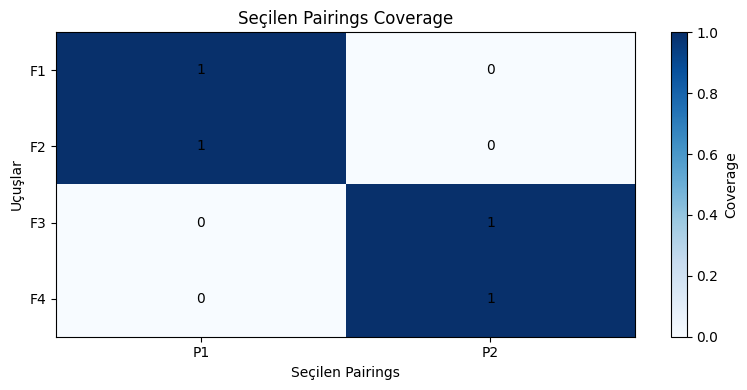

In [ ]:
def plot_pairing_coverage(A, selected, title="Seçilen Pairings Coverage"):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Heatmap benzeri
    data = A[selected].astype(float) if selected else A.iloc[:, :0]
    im = ax.imshow(data.values, cmap="Blues", aspect="auto")

    ax.set_xticks(range(len(selected)))
    ax.set_xticklabels(selected)
    ax.set_yticks(range(len(A.index)))
    ax.set_yticklabels(A.index)
    ax.set_xlabel("Seçilen Pairings")
    ax.set_ylabel("Uçuşlar")
    ax.set_title(title)

    for i in range(len(A.index)):
        for j in range(len(selected)):
            ax.text(j, i, int(data.values[i, j]), ha="center", va="center", color="black")

    plt.colorbar(im, ax=ax, label="Coverage")
    plt.tight_layout()
    plt.show()

plot_pairing_coverage(A, selected_pairings)

## 8. Crew Rostering’e Kısa Bakış

Pairing’ler üretildikten sonra **rostering** aşamasında her pairing bir mürettebat üyesine atanır.

Basit bir QUBO iskeleti:

- $y_{kp} = 1$ → $k$ kişisi $p$ pairing’ini alır
- Kısıtlar:
  - Her pairing tam bir kişiye atanmalı
  - Kişinin aylık uçuş saati / duty limiti aşılmamalı
  - Yetkinlik (type rating) uygun olmalı
  - Preferanslar soft constraint olarak ceza ile eklenebilir

Bu da yine Set Partitioning / Assignment + capacity constraints → QUBO’ya dönüştürülebilir.  
Gerçek hayatta genellikle **column generation + local search** veya **metaheuristics** kullanılır; quantum tarafında hybrid quantum-classical (QAOA + classical repair) yaklaşımları araştırılmaktadır.

## 9. Öğrenci Alıştırmaları

1. **Penalty hassasiyeti:** `penalty` değerini 10, 30, 100 olarak değiştirip QAOA sonuçlarının nasıl değiştiğini gözlemleyin. Çok küçük penalty kısıt ihlaline, çok büyük ise optimizasyonu zorlaştırır.

2. **QAOA derinliği:** `reps=1`, `reps=3` deneyin. Daha fazla katman daha iyi yaklaşım sağlar ama devre derinliği ve parametre sayısı artar.

3. **Yeni pairing ekleyin:** P6 = {F2, F4} (ölü baş / deadhead içeren hayali bir pairing) ekleyip modeli yeniden çözün.

4. **Rostering uzantısı:** 3 mürettebat üyesi varsayın. Pairing atamasını binary değişkenlerle modelleyip basit bir QUBO yazın.

5. **Gerçek veri:** Open-source flight schedule verisi (ör. Bureau of Transportation Statistics) ile küçük bir pairing generation yazmayı deneyin (ileri seviye).

## 10. Kaynaklar ve İleri Okuma

- **ArXiv 2504.11899** – *Variational Quantum Optimization Benchmark Suite for Airline Crew Pairing and More* (2025)
- Stoebke et al. – *A comparative study of crew pairing optimization formulations: Preparing for quantum computing* (2026)
- Qiskit Optimization Documentation & QAOA tutorials
- Lucas, A. – *Ising formulations of many NP problems* (Frontiers in Physics, 2014)
- Air France-KLM & Quantum Application Lab – Quantum Annealing for Rostering (2024)

---

**Hazırlayan notu:** Bu notebook eğitim amaçlıdır. Endüstriyel ölçekte quantum avantajı henüz gösterilmemiştir; asıl değer formülasyon bilgisi, hybrid yöntemler ve gelecekteki donanıma hazırlıktır.

Başarılar! 🚀  
Sorularınız için ders sırasında veya ofis saatlerinde buluşabiliriz.